In [ ]:

library(org.Mm.eg.db)#
library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(fgsea)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(DESeq2)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
#library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
library(corrplot)
library(edgeR)
library(ggplot2)
library(FactoMineR)   
library(factoextra)   
library(corrplot)     
library(pheatmap)
library(tidyverse)
library(clusterProfiler)  
library(org.Hs.eg.db)     
library(GSEABase)    
library(ggplot2)    
library(tidyverse)   
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)


In [2]:
drds <- "../03FN_RDS/"
setwd("/03fig1/")

In [12]:
sp <-readRDS("sample_bulk.RDS")

In [13]:
####gs
######GO KEGG
####let us find something
####GSVA genesets
genesets <- msigdbr(species = "Mus musculus", category = "C5")#msigdbr导入基因集
genesets <- subset(genesets, select = c("gs_name","gene_symbol")) %>% as.data.frame()#as data.frame
genesets$gs_name <- str_replace(genesets$gs_name,"GOBP_","")
head(genesets)
genesets$gs_name <- gsub("_", " ", genesets$gs_name)
genesets$gs_name <- tolower(substring(genesets$gs_name, 1))
# genesets <- split(genesets$gene_symbol, genesets$gs_name)#
head(genesets)

,gs_name,gene_symbol
,<chr>,<chr>
1,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Aasdhppt
2,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Aldh1l1
3,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Aldh1l2
4,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Mthfd1
5,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Mthfd1l
6,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Mthfd2l


,gs_name,gene_symbol
,<chr>,<chr>
1,10 formyltetrahydrofolate metabolic process,Aasdhppt
2,10 formyltetrahydrofolate metabolic process,Aldh1l1
3,10 formyltetrahydrofolate metabolic process,Aldh1l2
4,10 formyltetrahydrofolate metabolic process,Mthfd1
5,10 formyltetrahydrofolate metabolic process,Mthfd1l
6,10 formyltetrahydrofolate metabolic process,Mthfd2l


In [14]:
genesets1 <- msigdbr(species = "Mus musculus", category = "C2")#msigdbr导入基因集
genesets1 <- subset(genesets1, select = c("gs_name","gene_symbol")) %>% as.data.frame()#as data.frame
genesets1$gs_name <- str_replace(genesets1$gs_name,"KEGG_","")
head(genesets1)
genesets1$gs_name <- gsub("_", " ", genesets1$gs_name)
genesets1$gs_name <- tolower(substring(genesets1$gs_name, 1))
# genesets <- split(genesets$gene_symbol, genesets$gs_name)#
genesets1$gs_name <- paste0("C2 ",genesets1$gs_name)
head(genesets1)

,gs_name,gene_symbol
,<chr>,<chr>
1,ABBUD_LIF_SIGNALING_1_DN,Ahnak
2,ABBUD_LIF_SIGNALING_1_DN,Alcam
3,ABBUD_LIF_SIGNALING_1_DN,Ankrd40
4,ABBUD_LIF_SIGNALING_1_DN,Arid1a
5,ABBUD_LIF_SIGNALING_1_DN,Bckdhb
6,ABBUD_LIF_SIGNALING_1_DN,AU021092


,gs_name,gene_symbol
,<chr>,<chr>
1,C2 abbud lif signaling 1 dn,Ahnak
2,C2 abbud lif signaling 1 dn,Alcam
3,C2 abbud lif signaling 1 dn,Ankrd40
4,C2 abbud lif signaling 1 dn,Arid1a
5,C2 abbud lif signaling 1 dn,Bckdhb
6,C2 abbud lif signaling 1 dn,AU021092


In [15]:
genesets <- rbind(genesets1,genesets)

In [43]:
gss <- genesets[which(genesets$gs_name%in%c("regulation of inflammatory response","regulation of leukocyte migration","phototransduction",
                                           "glutamate receptor signaling pathway","C2 wp g protein signaling pathways","C2 reactome apoptosis","positive regulation of autophagy",
                                          "ribose phosphate metabolic process","small molecule catabolic process")),]

In [49]:
library(Seurat)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [59]:
exp <- as.data.frame(sp@assays$RNA$data)
head(exp)

,Sham2,Sham1,RIR2,RIR1,RIR3,Sham4,RIR4,RIR5,Sham5,RIR6,Sham3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610005C13Rik,0.002594047,0.024055156,0.021174146,0.000000000,0.020784588,0.008040050,0.005328588,0.004011396,0.032027354,0.014773611,0.007448607
0610006L08Rik,0.000000000,0.002701549,0.000000000,0.014782209,0.008134307,0.006437203,0.006390907,0.003010055,0.004059966,0.004050861,0.007448607
0610009B22Rik,0.642539273,0.646552189,0.336817895,0.415589294,0.500713500,0.551703543,0.427365180,0.468686240,0.592342620,0.436947823,0.510065971
0610010F05Rik,0.232966207,0.233018289,0.223691117,0.194287091,0.229411079,0.246318572,0.217176651,0.245567906,0.203029082,0.220139549,0.198692356
0610010K14Rik,0.281168474,0.330924196,0.240656935,0.249160646,0.269414322,0.291955368,0.233383948,0.263485897,0.287877497,0.283246368,0.288888935
0610012D04Rik,0.002594047,0.002701549,0.003052466,0.002973975,0.000000000,0.000000000,0.003200559,0.001004359,0.001355154,0.000000000,0.000000000


In [64]:
library(GSVA)

In [124]:
gsvapar <- gsvaParam(as.matrix(exp1), gs)
gsva_es <- gsva(gsvapar)

ℹ GSVA version 2.0.4

ℹ Calculating GSVA ranks

ℹ kcdf='auto' (default)

ℹ GSVA dense (classical) algorithm

ℹ Row-wise ECDF estimation with Gaussian kernels

ℹ Calculating GSVA column ranks

! Duplicated gene IDs removed from gene set C2 reactome apoptosis

! Duplicated gene IDs removed from gene set C2 wp g protein signaling pathways

! Duplicated gene IDs removed from gene set glutamate receptor signaling pathway

! Duplicated gene IDs removed from gene set phototransduction

! Duplicated gene IDs removed from gene set regulation of inflammatory response

! Duplicated gene IDs removed from gene set regulation of leukocyte migration

! Duplicated gene IDs removed from gene set ribose phosphate metabolic process

! Duplicated gene IDs removed from gene set small molecule catabolic process

ℹ Calculating GSVA scores

✔ Calculations finished



In [126]:
colnames(gsva_es)
ord <- c("RIR1","RIR2","RIR3","RIR4","RIR5","RIR6","Sham1","Sham2","Sham3","Sham4","Sham5")
gsva <- subset(gsva_es,select=ord)

[1] "Sham2" "Sham1" "RIR2"  "RIR1"  "RIR3"  "Sham4" "RIR4"  "RIR5"  "Sham5"
[10] "RIR6"  "Sham3"

In [163]:
exp <- subset(exp,select=ord)

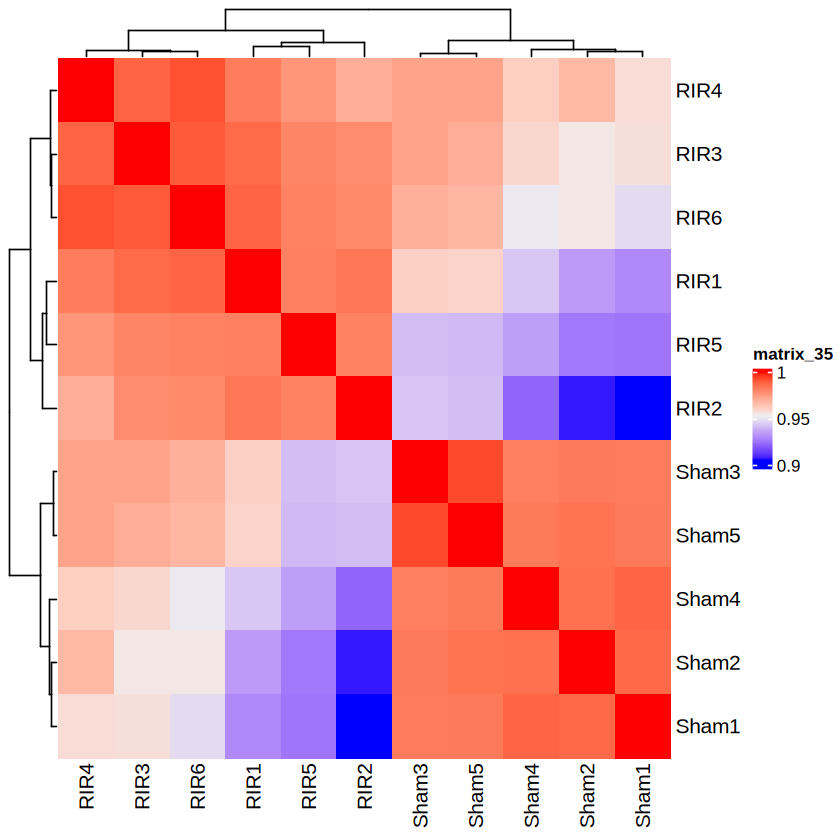

In [166]:
exp1 <- exp[names(sort(apply(exp, 1, mad),decreasing = T)[1:2000]),]
exp1 <- subset(exp1,select=ord)
Heatmap(cor(exp1))

In [131]:
rownames(gsva)

[1] "C2 reactome apoptosis"               
[2] "C2 wp g protein signaling pathways"  
[3] "glutamate receptor signaling pathway"
[4] "phototransduction"                   
[5] "positive regulation of autophagy"    
[6] "regulation of inflammatory response" 
[7] "regulation of leukocyte migration"   
[8] "ribose phosphate metabolic process"  
[9] "small molecule catabolic process"

In [352]:
g <- c('regulation of inflammatory response','regulation of leukocyte migration',"phototransduction","ribose phosphate metabolic process")
gg <- t(gsva[g,])

In [250]:
colnames(exp1)   # 或 rownames(exp1) 取决于数据布局
# 查看 mantel 中的名称
mantel$spec
mantel$env

[1] "RIR1"  "RIR2"  "RIR3"  "RIR4"  "RIR5"  "RIR6"  "Sham1" "Sham2" "Sham3"
[10] "Sham4" "Sham5"

[1] "phototransduction"                   "phototransduction"                  
 [3] "phototransduction"                   "phototransduction"                  
 [5] "phototransduction"                   "phototransduction"                  
 [7] "phototransduction"                   "phototransduction"                  
 [9] "phototransduction"                   "phototransduction"                  
[11] "phototransduction"                   "ribose phosphate metabolic process" 
[13] "ribose phosphate metabolic process"  "ribose phosphate metabolic process" 
[15] "ribose phosphate metabolic process"  "ribose phosphate metabolic process" 
[17] "ribose phosphate metabolic process"  "ribose phosphate metabolic process" 
[19] "ribose phosphate metabolic process"  "ribose phosphate metabolic process" 
[21] "ribose phosphate metabolic process"  "ribose phosphate metabolic process" 
[23] "regulation of inflammatory response" "regulation of inflammatory response"
[25] "regulation of inflammatory response" "regulation of inflammatory response"
[27] "regulation of inflammatory response" "regulation of inflammatory response"
[29] "regulation of inflammatory response" "regulation of inflammatory response"
[31] "regulation of inflammatory response" "regulation of inflammatory response"
[33] "regulation of inflammatory response" "regulation of leukocyte migration"  
[35] "regulation of leukocyte migration"   "regulation of leukocyte migration"  
[37] "regulation of leukocyte migration"   "regulation of leukocyte migration"  
[39] "regulation of leukocyte migration"   "regulation of leukocyte migration"  
[41] "regulation of leukocyte migration"   "regulation of leukocyte migration"  
[43] "regulation of leukocyte migration"   "regulation of leukocyte migration"

[1] "RIR1"  "RIR2"  "RIR3"  "RIR4"  "RIR5"  "RIR6"  "Sham1" "Sham2" "Sham3"
[10] "Sham4" "Sham5" "RIR1"  "RIR2"  "RIR3"  "RIR4"  "RIR5"  "RIR6"  "Sham1"
[19] "Sham2" "Sham3" "Sham4" "Sham5" "RIR1"  "RIR2"  "RIR3"  "RIR4"  "RIR5" 
[28] "RIR6"  "Sham1" "Sham2" "Sham3" "Sham4" "Sham5" "RIR1"  "RIR2"  "RIR3" 
[37] "RIR4"  "RIR5"  "RIR6"  "Sham1" "Sham2" "Sham3" "Sham4" "Sham5"

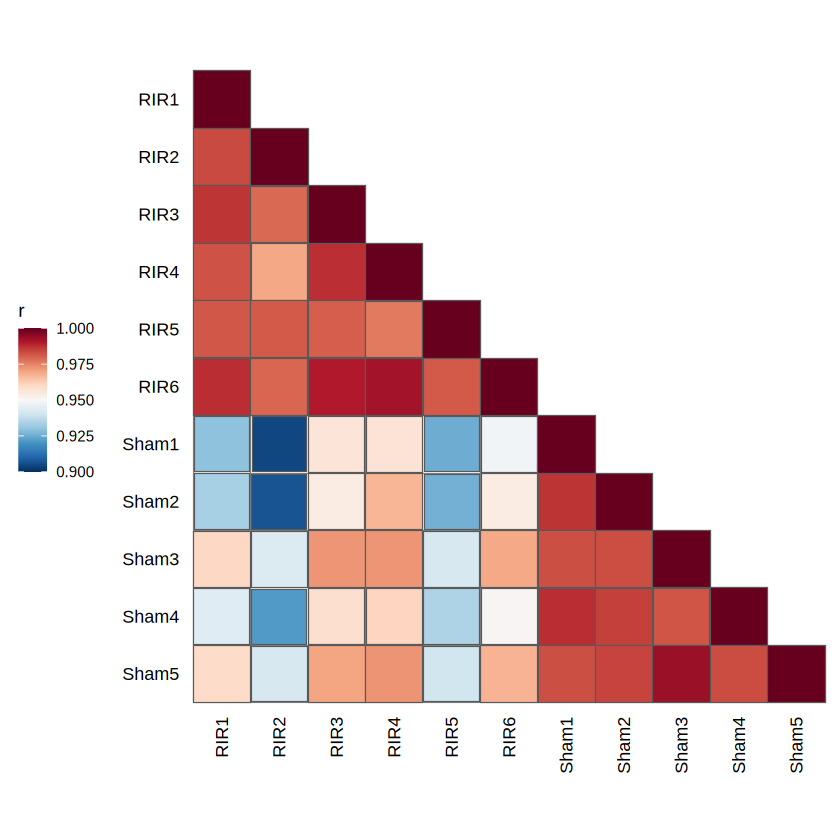

In [497]:
heatmap <- qcorrplot(
  correlate(exp1),  
  type = "lower",      
  diag = TRUE   
) +
  geom_square() +     
  scale_fill_gradientn(
    colours = rev(RColorBrewer::brewer.pal(11, "RdBu")),  
    limits = c(0.9, 1)
  )
print(heatmap)

In [354]:
m <- melt(gg)
colnames(m) <- c("env","spec","r")
# 'spec''env''r''p''rd''pd'

In [355]:
head(mantel)
head(m)

,spec,env,r,p,rd,pd
,<fct>,<fct>,<dbl>,<dbl>,<chr>,<chr>
1,phototransduction,RIR1,-0.07066638,-0.07066638,< 0.2,< 0.2
2,phototransduction,RIR2,-0.17850687,-0.17850687,< 0.2,< 0.2
3,phototransduction,RIR3,-0.71842731,-0.71842731,< 0.2,< 0.2
4,phototransduction,RIR4,-0.45830310,-0.45830310,< 0.2,< 0.2
5,phototransduction,RIR5,-0.74968162,-0.74968162,< 0.2,< 0.2
6,phototransduction,RIR6,-0.34780247,-0.34780247,< 0.2,< 0.2


,env,spec,r
,<fct>,<fct>,<dbl>
1,RIR1,regulation of inflammatory response,0.3826217682
2,RIR2,regulation of inflammatory response,0.4208938159
3,RIR3,regulation of inflammatory response,0.2702713779
4,RIR4,regulation of inflammatory response,0.0008036257
5,RIR5,regulation of inflammatory response,0.3348907705
6,RIR6,regulation of inflammatory response,0.1021448463


In [463]:
m$rd <- "-0.2 - 0.2"
m[which(m$r< -0.2),]$rd <- "< -0.2"
m[which(m$r>0.2),]$rd <- ">= 0.2"

In [464]:
m$pd <- m$rd

In [465]:
m$p <- m$r

In [466]:
mantel <- subset(m,select=c('spec','env','r','p','rd','pd'))

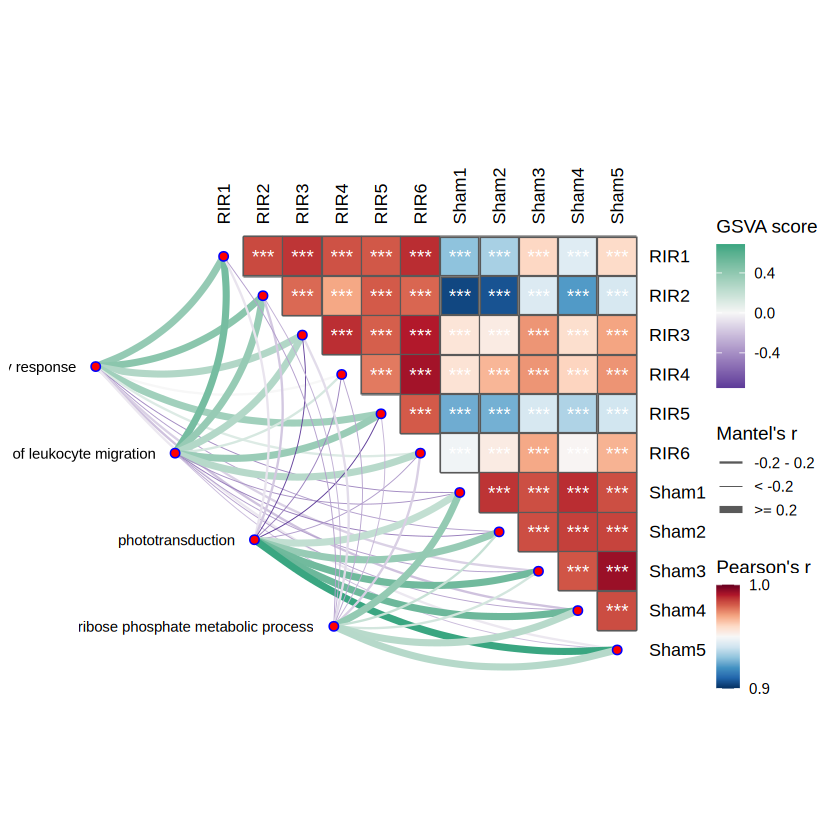

In [519]:
p1 <- qcorrplot(
  correlate(exp1),
                grid_col = "grey50",
                grid_size = 0.5,
                type = "upper", 
                diag = FALSE) +
  geom_square() +
  geom_mark(size = 4,
            only_mark = TRUE,
            sig_level = c(0.05, 0.01, 0.001),
            sig_thres = 0.05,
            colour = 'white') +
  geom_couple(data = mantel,
              aes(color = r, size = rd),
              label.size = 3,
              label.family = "",
              label.fontface = 1,
              nudge_x = 0.5,
              curvature = 0.2,
              point_fill = "white",
              point_color = "gray50") +
  scale_fill_gradientn(
    colours = rev(RColorBrewer::brewer.pal(11, "RdBu")),
    limits = c(0.9, 1),
    breaks = seq(0.9, 1, 0.1)
  ) +
scale_color_gradient2(
  low = "#5e3c99",      
  mid = "#f7f7f7",      
  high = "#1b9e77",  
  midpoint = 0,
  guide = guide_colorbar(title = "GSVA score", order = 2)
)+
  scale_size_manual(
    values = c("< -0.2" = 0.2, "-0.2 - 0.2" = 0.5, ">= 0.2" = 1.5),
    guide = guide_legend(title = "Mantel's r", order = 2, keyheight = unit(0.5, "cm"))
  )+
  guides(
    fill = guide_colorbar(title = "Pearson's r", 
                          keyheight = unit(2.2, "cm"),
                          keywidth = unit(0.5, "cm"),
                          order = 3)
  ) +
  theme(legend.box.spacing = unit(0, "pt"))
p1
ggsave("fig1C2.pdf",p1,width = 7,height = 7)